## Run inference
### Using TorchIO to replace the standard pytorch dataloader and the custom patch-processor. 

In [1]:
import torch
import torchio as tio
import os
import numpy as np
from skimage import io
import sys 
import yaml
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from models import networks
from models import create_model
from data import base_dataset



### Set the parameters for the inference 

In [2]:
yaml_file = '../configs/siimulation-inference-config-20250318-1.yaml'
with open(yaml_file, "r") as f:
    yaml_config = yaml.safe_load(f)

In [3]:
class DummpyOptions():
    def __init__(self):

        self.initialized = False
    
    def gather_options(self, yaml_config):
        
        recursive_attr(self, yaml_config)
        return self
    
@staticmethod
def recursive_attr(class_instance, dict_):
    '''
    If YAML file contains a nested dictionary, this function will iterate to the deepest depth to parse all configs
    '''
    for k, v in dict_.items():
        if isinstance(v, dict):
            new_dict =  dict(zip(v.keys(), v.values()))
            recursive_attr(class_instance, new_dict)
        else:
            setattr(class_instance, k, v)


In [4]:
opt = DummpyOptions()
opt.gather_options(yaml_config)

model = create_model(opt)  # create a model given opt.model and other options
model.setup(opt) 

initialize network with kaiming
model [TestModel] was created
loading the model from /scratch/park/checkpoints/models/DeepClarity/haystack-surt-randomized-projection-depth_exp_250317-171056/iter_47500_net_G_A.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 7.077 M
-----------------------------------------------


/g/kreshuk/park/code/neuroclear/models/base_model.py:199: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location=str(self.device))


## Save Directory

In [5]:
data_source_folder = opt.data_source
data_ref_folder = opt.data_reference
data_target_folder = opt.data_target

In [6]:
data_source_folder

'/scratch/park/data/simulation_data/haystack/6000-lines-blurred-by-gaublur-std-4/bornandwolf_noisy_25.89'

In [7]:
import os

# Fetch all 'tif' images in the data_source_folder
tif_images_source = [os.path.join(data_source_folder, f) for f in os.listdir(data_source_folder) if f.endswith('.tif') or f.endswith('.tiff')]
print(tif_images_source)
print(f"image # from source: {len(tif_images_source)}")

tif_images_ref = [os.path.join(data_ref_folder, f) for f in os.listdir(data_ref_folder) if f.endswith('.tif') or f.endswith('.tiff')]
print(tif_images_ref)
print(f"image # from reference: {len(tif_images_ref)}")

tif_images_target = [os.path.join(data_target_folder, f) for f in os.listdir(data_target_folder) if f.endswith('.tif') or f.endswith('.tiff')]
print(tif_images_target)
print(f"image # from target: {len(tif_images_target)}")


['/scratch/park/data/simulation_data/haystack/6000-lines-blurred-by-gaublur-std-4/bornandwolf_noisy_25.89/blurred_bornandwolf_noisy_25.89.tiff']
image # from source: 1
['/scratch/park/data/simulation_data/haystack/6000-lines-blurred-by-gaublur-std-4/GT/GT.tiff']
image # from reference: 1
['/scratch/park/data/simulation_data/haystack/6000-lines-blurred-by-gaublur-std-4/blurred/blurred.tiff']
image # from target: 1


In [8]:
index = 0

In [9]:
os.path.basename(tif_images_source[index])[:-4]

'blurred_bornandwolf_noisy_25.89.'

In [10]:
import tifffile as tiff

save_dir = '/scratch/park/results/DeepClarity/20250318/' + opt.name 
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

save_output_file = os.path.join(save_dir, opt.name + f'{os.path.basename(tif_images_source[index])[:-4]}_output.tif')
save_input_file = os.path.join(save_dir, f'{os.path.basename(tif_images_source[index])[:-4]}_input.tif')

In [11]:
test_source_img_raw = io.imread(tif_images_source[index])
test_target_img_raw= io.imread(tif_images_target[index])
test_GT_img_raw= io.imread(tif_images_ref[index])


test_source_img = np.transpose(test_source_img_raw, axes=(2, 1, 0))
test_target_img = np.transpose(test_target_img_raw, axes=(2, 1, 0))
test_GT_img = np.transpose(test_GT_img_raw, axes=(2, 1, 0))

# Add an extra dimension to the tensors
test_source_img = torch.unsqueeze(torch.tensor(test_source_img), 0)[:,:350,:350,:350]
test_target_img = torch.unsqueeze(torch.tensor(test_target_img), 0)[:,:350,:350,:350]
test_GT_img = torch.unsqueeze(torch.tensor(test_GT_img), 0)[:,:350,:350,:350]


print(test_source_img.shape)

torch.Size([1, 350, 350, 350])


### Note: TorchIO handles the dimension as in reverse: (C, W, H, D) or (C, X, Y, Z). 

In [12]:
subject_source = tio.Subject(
    image=tio.ScalarImage(tensor=test_source_img),
)
patch_size = opt.patch_size
patch_size = [patch_size[1], patch_size[2], patch_size[0]]
patch_overlap = opt.patch_overlap

In [13]:
grid_sampler = tio.inference.GridSampler(subject_source, patch_size, patch_overlap)
patch_loader = tio.SubjectsLoader(grid_sampler, batch_size=1)
aggregator_output = tio.inference.GridAggregator(grid_sampler, overlap_mode = 'hann')
aggregator_input = tio.inference.GridAggregator(grid_sampler, overlap_mode = 'hann')

In [14]:
len(patch_loader)

192

In [15]:
grid_sampler[0].image['data'].shape

torch.Size([1, 128, 128, 48])

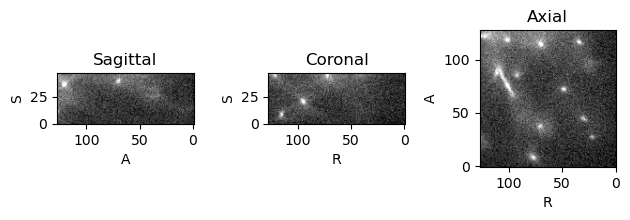

In [16]:
grid_sampler[0].image.plot()

In [17]:
from tqdm.notebook import tqdm

# Iterate over the patches and place them back into the reconstructed volume
with torch.no_grad():
    for patch in tqdm(patch_loader, desc="Processing patches"):
        patch_data = patch['image'][tio.DATA] # (B, C, H, W, D)
        patch_data = patch_data.permute(0, 1, 4, 2, 3) # (B, C, D, H, W)
        patch_data = (patch_data / (2**16*1.0 - 1))
        patch_data_dict = {'src': patch_data, 'src_paths': 'dummy'}
        
        model.set_input(patch_data_dict)
        model.test()
        output = model.get_current_visuals()['fake']
        input_ = model.get_current_visuals()['real']

        output = output.permute(0, 1, 3, 4, 2) # (B, C, H, W, D)
        input_ = input_.permute(0, 1, 3, 4, 2)
        aggregator_output.add_batch(output, patch[tio.LOCATION])
        aggregator_input.add_batch(input_, patch[tio.LOCATION])

        # print(patch_data.shape)

Processing patches:   0%|          | 0/192 [00:00<?, ?it/s]

## Visualize one block 

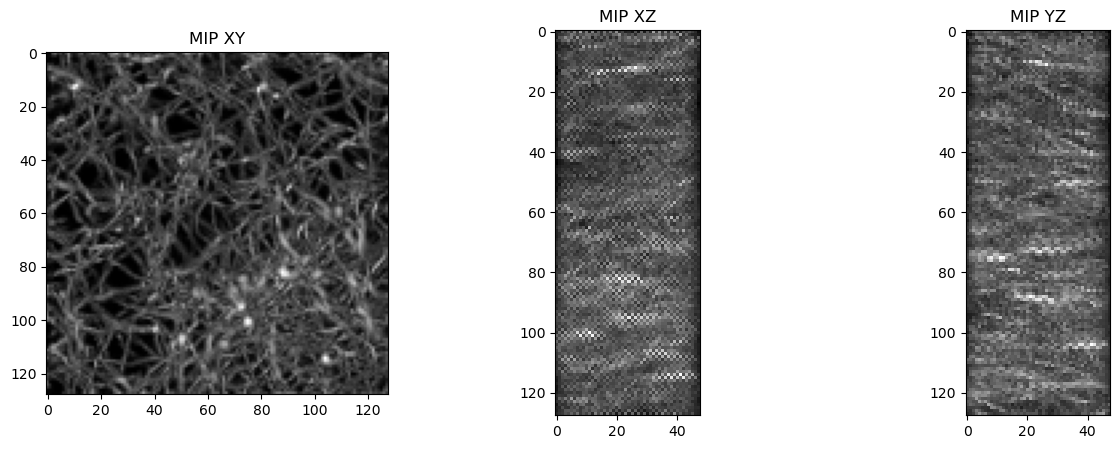

In [18]:
import matplotlib.pyplot as plt

# Convert the tensor to numpy array for visualization
output_np = output.cpu().numpy().squeeze()


# Compute the maximum intensity projection along each axis
mip_xy = np.max(output_np, axis=2)
mip_xz = np.max(output_np, axis=1)
mip_yz = np.max(output_np, axis=0)

# Plot the maximum intensity projections
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mip_xy, cmap='gray')
axes[0].set_title('MIP XY')

axes[1].imshow(mip_xz, cmap='gray')
axes[1].set_title('MIP XZ')

axes[2].imshow(mip_yz, cmap='gray')
axes[2].set_title('MIP YZ')

plt.show()

In [19]:
output_tensor = aggregator_output.get_output_tensor().squeeze()
output_tensor = output_tensor.permute(2, 0, 1) # (B, C, D, H, W)

input_tensor = aggregator_input.get_output_tensor().squeeze()
input_tensor = input_tensor.permute(2, 0, 1)

test_GT_img = test_GT_img.squeeze().permute(2,0,1)

In [20]:
output_tensor.shape

torch.Size([350, 350, 350])

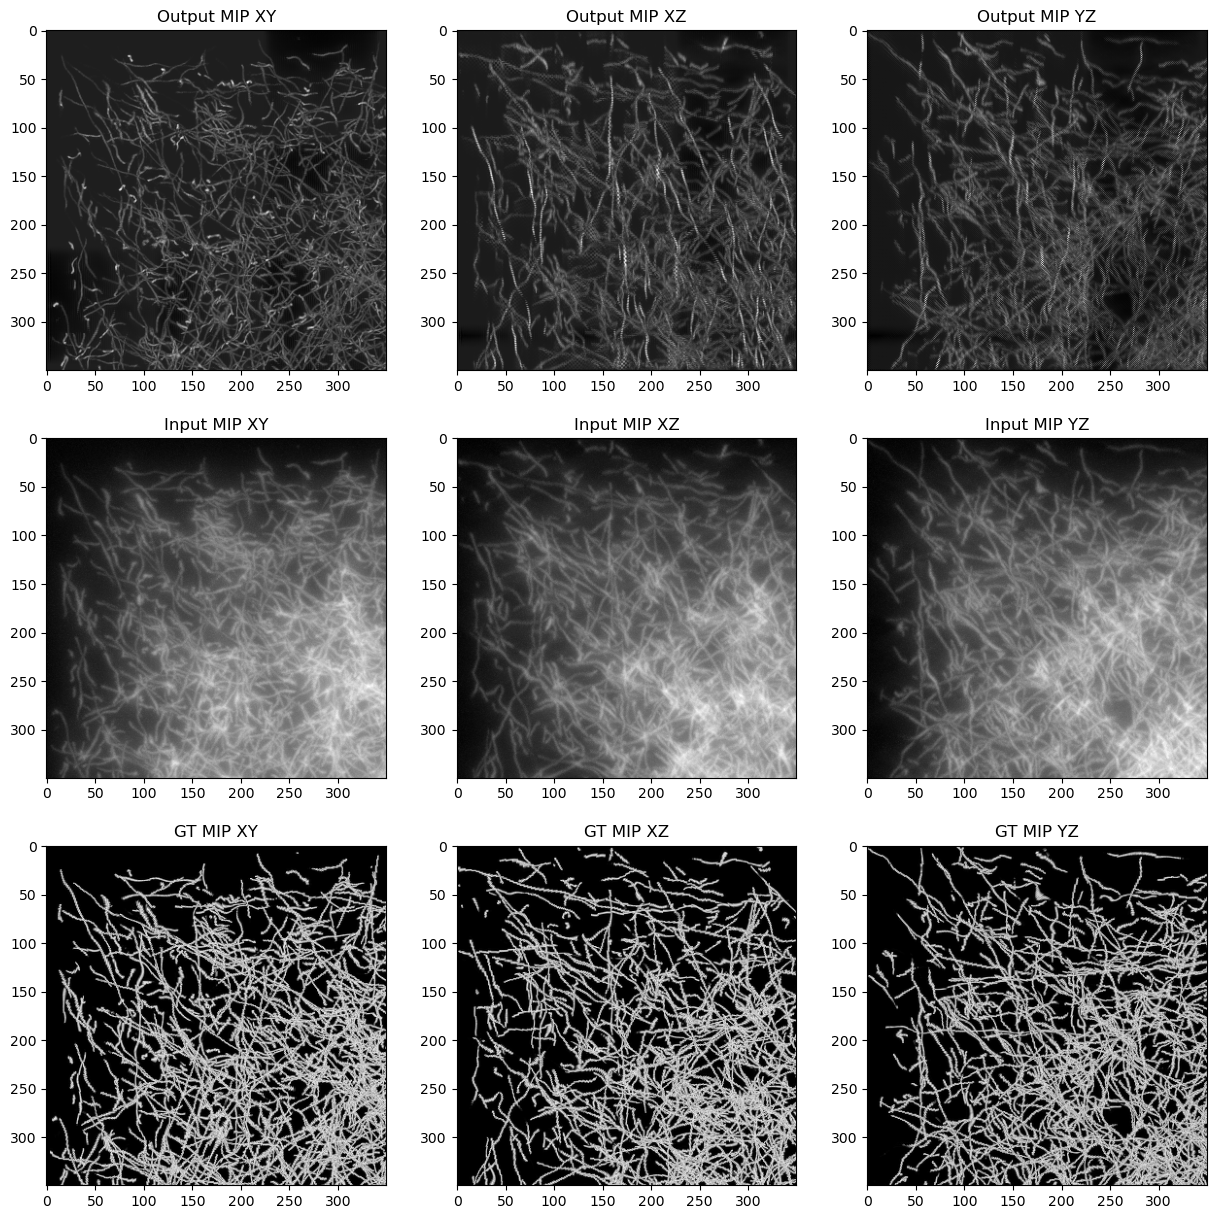

In [21]:
# Convert the input tensor to numpy array for visualization
input_np = input_tensor.cpu().numpy().squeeze()
output_np = output_tensor.cpu().numpy().squeeze()
gt_np = test_GT_img.cpu().numpy().squeeze()

# Define the middle slice index and the range for projection
middle_z = output_np.shape[0] // 2
middle_y = output_np.shape[1] // 2
middle_x = output_np.shape[2] // 2
depth = 30

# Compute the maximum intensity projection along each axis for output
mip_xy_output = np.max(output_np[middle_z-depth//2:middle_z+depth//2, :, :], axis=0)
mip_xz_output = np.max(output_np[:, middle_y-depth//2:middle_y+depth//2, :], axis=1)
mip_yz_output = np.max(output_np[:, :, middle_x-depth//2:middle_x+depth//2], axis=2)

# Compute the maximum intensity projection along each axis for input
mip_xy_input = np.max(input_np[middle_z-depth//2:middle_z+depth//2, :, :], axis=0)
mip_xz_input = np.max(input_np[:, middle_y-depth//2:middle_y+depth//2, :], axis=1)
mip_yz_input = np.max(input_np[:, :, middle_x-depth//2:middle_x+depth//2], axis=2)

# Compute the maximum intensity projection along each axis for ground truth
mip_xy_gt = np.max(gt_np[middle_z-depth//2:middle_z+depth//2, :, :], axis=0)
mip_xz_gt = np.max(gt_np[:, middle_y-depth//2:middle_y+depth//2, :], axis=1)
mip_yz_gt = np.max(gt_np[:, :, middle_x-depth//2:middle_x+depth//2], axis=2)

# Plot the maximum intensity projections
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Output projections
axes[0, 0].imshow(mip_xy_output, cmap='gray')
axes[0, 0].set_title('Output MIP XY')

axes[0, 1].imshow(mip_xz_output, cmap='gray')
axes[0, 1].set_title('Output MIP XZ')

axes[0, 2].imshow(mip_yz_output, cmap='gray')
axes[0, 2].set_title('Output MIP YZ')

# Input projections
axes[1, 0].imshow(mip_xy_input, cmap='gray')
axes[1, 0].set_title('Input MIP XY')

axes[1, 1].imshow(mip_xz_input, cmap='gray')
axes[1, 1].set_title('Input MIP XZ')

axes[1, 2].imshow(mip_yz_input, cmap='gray')
axes[1, 2].set_title('Input MIP YZ')

# Ground truth projections
axes[2, 0].imshow(mip_xy_gt, cmap='gray')
axes[2, 0].set_title('GT MIP XY')

axes[2, 1].imshow(mip_xz_gt, cmap='gray')
axes[2, 1].set_title('GT MIP XZ')

axes[2, 2].imshow(mip_yz_gt, cmap='gray')
axes[2, 2].set_title('GT MIP YZ')

plt.show()

In [22]:
output_np = output_tensor.cpu().numpy().squeeze()


In [23]:
# Normalize the output_np array to the range [0, 65535] for 16-bit
output_np = np.clip(output_np, 0, 1)
output_np = (output_np - output_np.min()) / (output_np.max() - output_np.min())
output_np = (output_np * 65535).astype(np.uint16)

input_np = (input_np - input_np.min()) / (input_np.max() - input_np.min())
input_np = (input_np * 65535).astype(np.uint16)

gt_np = (gt_np - gt_np.min()) / (gt_np.max() - gt_np.min())
gt_np = (gt_np * 65535).astype(np.uint16)

# Save the numpy arrays as TIFF files
tiff.imwrite(save_output_file, output_np)
tiff.imwrite(save_input_file, input_np)

save_gt_file = os.path.join(save_dir, f'{os.path.basename(tif_images_source[index])[:-4]}_gt.tif')
tiff.imwrite(save_gt_file, gt_np)


In [24]:
# Normalize the output_np array to the range [0, 255] for 8-bit
output_np = np.clip(output_np, 0, None)
output_np = (output_np - output_np.min()) / (output_np.max() - output_np.min())
output_np = (output_np * 255).astype(np.uint8)

input_np = (input_np - input_np.min()) / (input_np.max() - input_np.min())
input_np = (input_np * 255).astype(np.uint8)

gt_np = (gt_np - gt_np.min()) / (gt_np.max() - gt_np.min())
gt_np = (gt_np * 255).astype(np.uint8)



In [25]:
def calculate_psnr(input_np, gt_np):
    mse = np.mean((input_np - gt_np) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0  # Since the images are 8-bit
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

psnr_value = calculate_psnr(input_np, gt_np)
print(f"PSNR: {psnr_value} dB")


PSNR: 27.59037090204826 dB


In [26]:

psnr_value = calculate_psnr(output_np, gt_np)
print(f"PSNR: {psnr_value} dB")

PSNR: 37.63877990083902 dB


In [27]:
from skimage.metrics import structural_similarity as ssim

# Calculate MSSIM between input_np and gt_np
mssim_value = ssim(input_np, gt_np, data_range=gt_np.max() - gt_np.min())

print(f"MSSIM: {mssim_value}")

MSSIM: 0.04722377027572462


In [28]:

# Calculate MSSIM between input_np and gt_np
mssim_value = ssim(output_np, gt_np, data_range=gt_np.max() - gt_np.min())

print(f"MSSIM: {mssim_value}")

MSSIM: 0.5930308314396494


In [29]:
output_np.shape

(350, 350, 350)